# background_images \u2014 which half of the frame carries the signal?

The decisive experiment for the image stream. `blurred_images` showed AUC
falling by 0.178 (0.842 -> 0.664, converging on a colour-only floor) as
blur increased -- but blur destroys facial detail and framing *at the same
time*, so that 0.178 could have been faces, or could have been composition.
It could not tell the two apart.

This experiment splits the post-geometry image into face and not-face
directly, using the face box MTCNN already found at sigma=0
(`blurred_images`, reused here without re-detecting) and asks each half the
same question independently: mask out the face and keep the background, or
mask out the background and keep the face, or crop to the face alone and
throw the rest of the frame away entirely. Same manifest, same L2 logistic
regression behind a `StandardScaler`, same 5x10 repeated stratified CV,
same seed as `intact_images` and `blurred_images` throughout -- only the
transform changes.

Before any of that: a face box has a shape and a position, and if that
shape or position differs by class, a *fully masked* image could still leak
class information through the hole alone. That is checked first (Part 1
below) and used as one of the floors every masked arm is read against --
along with each arm's own colour-only floor, since masking changes an
image's colour statistics too. The comparison that matters throughout is
never against chance (0.5); it is each arm against its own floors.

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.background_images.config import Config
from experiments.background_images.pipeline import (
    GEOMETRY_FEATURE_NAMES,
    arm_masked_image,
    step_1_manifest,
    step_2_boxes,
    step_3_exclude_boxless,
    step_4_box_geometry,
    step_5_geometry_effect_sizes,
    step_6_geometry_probe,
    step_7_embeddings,
    step_8_verify_embeddings,
    step_9_probe,
    step_10_summary,
    step_11_colour_features,
    step_12_colour_probe,
)
from src.data.transforms import expand_box, geometry_stage
from src.evaluation.metrics import fold_metrics

cfg = Config(seed=42)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"arms: {cfg.arm_names}")
print(f"expand_tight: {cfg.expand_tight}, expand_wide: {cfg.expand_wide}")
print(f"data_root:  {cfg.data_root}")
print(f"output_dir: {cfg.output_dir}")
print(f"intact_cache_dir (row-subset source for the 'intact' arm): {cfg.intact_cache_dir}")
print(f"blurred_cache_dir (box source, not re-detected): {cfg.blurred_cache_dir}")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER
arms: ('intact', 'face_masked_1.0', 'face_masked_1.5', 'background_masked_1.5', 'face_crop_1.5')
expand_tight: 1.0, expand_wide: 1.5
data_root:  C:\Projects\Autism Screening\data\raw\images
output_dir: C:\Projects\Autism Screening\outputs\background_images
intact_cache_dir (row-subset source for the 'intact' arm): C:\Projects\Autism Screening\outputs\intact_images
blurred_cache_dir (box source, not re-detected): C:\Projects\Autism Screening\outputs\blurred_images


## 2. Manifest, and the one excluded image

Faces are never re-detected here: `blurred_images`'s cached sigma=0 MTCNN
boxes are reused directly. That cache found a face in 99.93%/100% of images
by class (2940 total), so exactly one image has no box. It, and only it,
is dropped -- from every arm, including `"intact"` -- so no comparison in
this notebook ever mixes a 2940-row number with a 2939-row one.

In [2]:
manifest_full = step_1_manifest(cfg)
boxes_full = step_2_boxes(manifest_full)
manifest, boxes, excluded = step_3_exclude_boxless(manifest_full, boxes_full)

print(f"full manifest: {len(manifest_full)} rows")
print(f"images with no sigma=0 box: {boxes_full['best_box'].isna().sum()}")
print(f"excluded image: {excluded['path']} (class={excluded['class_label']})")
print(f"manifest after exclusion: {len(manifest)} rows")
assert list(manifest["path"]) == list(boxes["path"]), "manifest and boxes must be row-aligned"
manifest.groupby(["split", "class_label"]).size().unstack()

2026-09-08 18:53:26,813 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-08 18:53:26,933 [INFO] experiments.background_images.pipeline: step_3_exclude_boxless: excluded path=C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg class=autistic -- 2939 rows remain


full manifest: 2940 rows
images with no sigma=0 box: 1
excluded image: C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg (class=autistic)
manifest after exclusion: 2939 rows


class_label,autistic,non_autistic
split,,
test,150,150
train,1192,1193
valid,127,127


## 3. Visual check: five arms side by side

Four images (2 autistic, 2 non_autistic), rendered across all five arms, so
the masking is inspectable rather than only asserted. The box (expanded by
1.5x, the "honest" factor used everywhere except `face_masked_1.0`) is
drawn on the intact column for reference.

The cell also confirms, on one real box, that `face_masked` and
`background_masked` at the same `expand` are exact complements: every
pixel is in exactly one of the two regions, never both, never neither.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd

from src.data.transforms import _box_mask  # noqa: F401 -- verification only, not used in any transform below

sample = pd.concat(
    [
        manifest.loc[manifest["class_label"] == "autistic"].sample(2, random_state=cfg.seed),
        manifest.loc[manifest["class_label"] == "non_autistic"].sample(2, random_state=cfg.seed),
    ]
).reset_index(drop=True)
box_by_path = dict(zip(boxes["path"], boxes["best_box"]))

# Exact-complement check (verification #3), on the first sample image's real box.
_check_box = box_by_path[sample.loc[0, "path"]]
_inside = _box_mask(_check_box, cfg.expand_wide, cfg.image_size)
_outside = ~_inside
print(
    f"complement check on a real box: {_inside.sum()} px inside + {_outside.sum()} px outside "
    f"= {_inside.sum() + _outside.sum()} = {cfg.image_size**2} total "
    f"(overlap={ (_inside & _outside).sum() }, gap={ (~(_inside | _outside)).sum() })"
)

arm_labels = {
    "intact": "intact",
    "face_masked_1.0": "face_masked\n(expand=1.0)",
    "face_masked_1.5": "face_masked\n(expand=1.5)",
    "background_masked_1.5": "background_masked\n(expand=1.5)",
    "face_crop_1.5": "face_crop\n(expand=1.5)",
}

fig, axes = plt.subplots(len(sample), len(cfg.arm_names), figsize=(3 * len(cfg.arm_names), 3 * len(sample)))
for row, (_, image_row) in enumerate(sample.iterrows()):
    geo = geometry_stage(Image.open(image_row["path"]), cfg.image_size)
    box = box_by_path[image_row["path"]]
    for col, arm in enumerate(cfg.arm_names):
        ax = axes[row, col]
        shown = arm_masked_image(arm, geo, box, cfg)
        ax.imshow(shown)
        if arm == "intact":
            x1, y1, x2, y2 = expand_box(box, cfg.expand_wide, cfg.image_size)
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                            edgecolor="red", facecolor="none", linewidth=2))
        ax.axis("off")
        if row == 0:
            ax.set_title(arm_labels[arm], fontsize=9)
        if col == 0:
            ax.text(-0.15, 0.5, image_row["class_label"], transform=ax.transAxes,
                     va="center", ha="right", fontsize=9, rotation=90)

fig.suptitle("The five arms: intact, face masked out, face masked in, face cropped")
fig.tight_layout()
plt.show()

## 4. Box geometry: does the mask shape alone encode class?

Four scalar features from each image's (unexpanded, clipped) box:
`box_area_fraction`, `box_centre_x`, `box_centre_y`, `box_aspect`. If these
differ by class, a fully-masked image could still leak class information
through the *shape of the hole*, independent of anything inside it -- the
same move as the colour-only floor in `blurred_images`, applied to
geometry instead of colour.

In [4]:
geometry_df = step_4_box_geometry(cfg, boxes)
effect_sizes = step_5_geometry_effect_sizes(geometry_df)
effect_sizes

,feature,n_autistic,n_non_autistic,mean_autistic,mean_non_autistic,cliffs_delta
0,box_area_fraction,1469,1470,0.586511,0.703925,-0.401130
1,box_centre_x,1469,1470,0.502125,0.503404,-0.012119
2,box_centre_y,1469,1470,0.550021,0.518560,0.351715
3,box_aspect,1469,1470,0.814975,0.827962,-0.098095


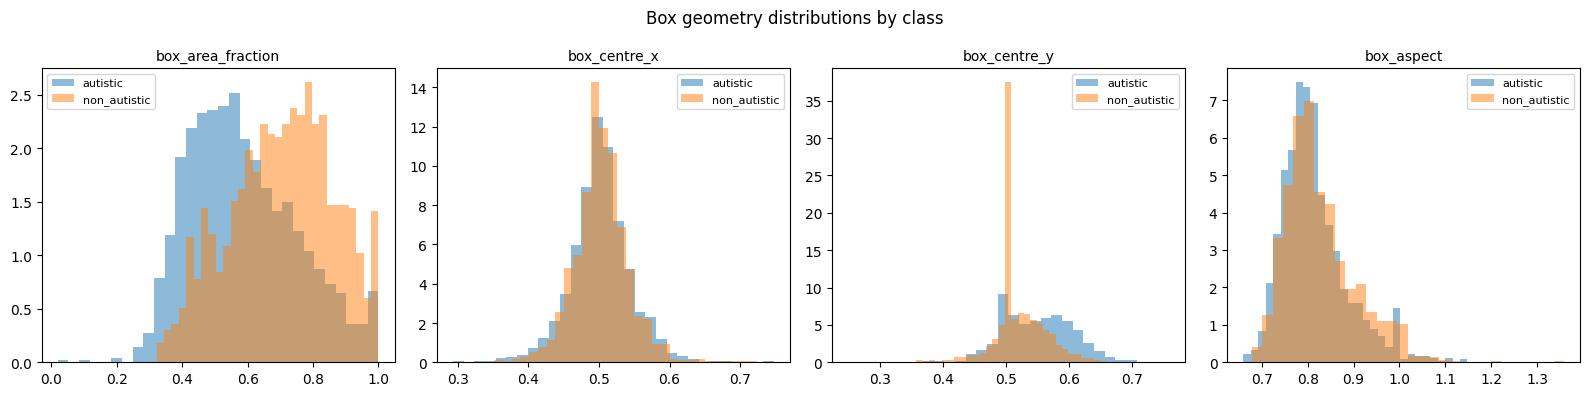

In [5]:
fig, axes = plt.subplots(1, len(GEOMETRY_FEATURE_NAMES), figsize=(4 * len(GEOMETRY_FEATURE_NAMES), 4))
for ax, feature in zip(axes, GEOMETRY_FEATURE_NAMES):
    for class_label, group in geometry_df.groupby("class_label"):
        ax.hist(group[feature], bins=30, alpha=0.5, density=True, label=class_label)
    ax.set_title(feature, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Box geometry distributions by class")
fig.tight_layout()
plt.show()

In [6]:
geometry_fold_results = step_6_geometry_probe(cfg, geometry_df, manifest)
geometry_probe_auc_mean = geometry_fold_results["roc_auc"].mean()
geometry_probe_auc_sd = geometry_fold_results["roc_auc"].std()
print(
    f"geometry-only probe (4 box features, {cfg.n_splits}x{cfg.n_repeats} CV): "
    f"ROC-AUC = {geometry_probe_auc_mean:.3f} +/- {geometry_probe_auc_sd:.3f}"
)
print(
    "This is well above chance -- every masked arm below must be read against "
    "this floor (and each arm's own colour floor), not against 0.5."
)

geometry-only probe (4 box features, 5x10 CV): ROC-AUC = 0.716 +/- 0.020
This is well above chance -- every masked arm below must be read against this floor (and each arm's own colour floor), not against 0.5.


## 5. Embeddings per arm

`"intact"` is a row-subset of the cached `intact_images` embeddings (2940
rows, selected down to the 2939 here) -- never re-extracted. The four
masked/cropped arms are each cached independently under
`outputs/background_images/`.

In [7]:
embeddings_by_arm, embedding_status = step_7_embeddings(cfg, manifest, manifest_full, boxes)
embedding_status

2026-09-08 18:53:28,366 [INFO] experiments.background_images.pipeline: step_7_embeddings: arm=intact row-subset of intact_images cache, shape=(2939, 2048)


2026-09-08 18:53:28,405 [INFO] experiments.background_images.pipeline: step_7_embeddings: arm=face_masked_1.0 using cached embeddings, shape=(2939, 2048)


2026-09-08 18:53:28,440 [INFO] experiments.background_images.pipeline: step_7_embeddings: arm=face_masked_1.5 using cached embeddings, shape=(2939, 2048)


2026-09-08 18:53:28,473 [INFO] experiments.background_images.pipeline: step_7_embeddings: arm=background_masked_1.5 using cached embeddings, shape=(2939, 2048)


2026-09-08 18:53:28,507 [INFO] experiments.background_images.pipeline: step_7_embeddings: arm=face_crop_1.5 using cached embeddings, shape=(2939, 2048)


,arm,n_rows,cache_hit_before_call,wall_clock_seconds
0,intact,2939,True,0.038139
1,face_masked_1.0,2939,True,0.000000
2,face_masked_1.5,2939,True,0.000000
3,background_masked_1.5,2939,True,0.000000
4,face_crop_1.5,2939,True,0.000000


In [8]:
verification = step_8_verify_embeddings(embeddings_by_arm, expected_rows=len(manifest))
verification

,arm,n_rows,rows_match_expected,n_nan,n_all_zero_rows
0,intact,2939,True,0,0
1,face_masked_1.0,2939,True,0,0
2,face_masked_1.5,2939,True,0,0
3,background_masked_1.5,2939,True,0,0
4,face_crop_1.5,2939,True,0,0


## 6. Per-fold results

Same probe, same folds, same seed, run independently on each arm's
embeddings.

In [9]:
fold_results = step_9_probe(cfg, embeddings_by_arm, manifest)
fold_results

,arm,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,intact,0,0,0.822557,0.739796,0.731293,0.748299
1,intact,0,1,0.840911,0.773810,0.775510,0.772109
2,intact,0,2,0.844486,0.760204,0.775510,0.744898
3,intact,0,3,0.846731,0.751701,0.734694,0.768707
4,intact,0,4,0.842098,0.756408,0.767918,0.744898
...,...,...,...,...,...,...,...
245,face_crop_1.5,9,0,0.836700,0.758503,0.744898,0.772109
246,face_crop_1.5,9,1,0.830094,0.750000,0.765306,0.734694
247,face_crop_1.5,9,2,0.834294,0.750000,0.724490,0.775510
248,face_crop_1.5,9,3,0.851624,0.772109,0.710884,0.833333


## 7. Summary: mean +/- sd per arm, paired deltas vs. intact

Because the seed, fold count and manifest order are unchanged across arms,
fold *k* of repeat *r* holds out the same images for every arm -- so the
AUC delta against `"intact"` below is a paired per-fold difference, not a
difference of independent means.

The colour-only floor is computed the same way, per arm, on that arm's own
masked image (masking changes an image's colour statistics: removing the
face leaves background colour, removing the background leaves skin
colour, so the floors are not interchangeable).

In [10]:
summary = step_10_summary(cfg, fold_results, baseline_arm="intact")
summary

,arm,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_intact_mean,auc_delta_vs_intact_sd
0,intact,0.843963,0.012148,0.765736,0.015789,0.762765,0.022664,0.768707,0.025721,0.000000,0.000000
1,face_masked_1.0,0.752225,0.020040,0.699554,0.018636,0.681964,0.028771,0.717143,0.025111,-0.091739,0.019139
2,face_masked_1.5,0.655812,0.017416,0.638528,0.014580,0.461545,0.028295,0.815510,0.023013,-0.188151,0.019501
3,background_masked_1.5,0.839155,0.011587,0.760531,0.011936,0.756164,0.025019,0.764898,0.023381,-0.004809,0.008105
4,face_crop_1.5,0.836011,0.011792,0.757432,0.013960,0.752415,0.026031,0.762449,0.023104,-0.007952,0.008954


In [11]:
colour_features_by_arm = step_11_colour_features(cfg, manifest, boxes)
colour_fold_results = step_12_colour_probe(cfg, colour_features_by_arm, manifest)
colour_summary = step_10_summary(cfg, colour_fold_results, baseline_arm="intact")
colour_summary

2026-09-08 18:54:18,493 [INFO] experiments.background_images.pipeline: step_11_colour_features: arm=intact using cached features


2026-09-08 18:54:18,503 [INFO] experiments.background_images.pipeline: step_11_colour_features: arm=face_masked_1.0 using cached features


2026-09-08 18:54:18,514 [INFO] experiments.background_images.pipeline: step_11_colour_features: arm=face_masked_1.5 using cached features


2026-09-08 18:54:18,524 [INFO] experiments.background_images.pipeline: step_11_colour_features: arm=background_masked_1.5 using cached features


2026-09-08 18:54:18,533 [INFO] experiments.background_images.pipeline: step_11_colour_features: arm=face_crop_1.5 using cached features


,arm,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,auc_delta_vs_intact_mean,auc_delta_vs_intact_sd
0,intact,0.663170,0.019412,0.621883,0.015775,0.632269,0.026159,0.611497,0.026007,0.000000,0.000000
1,face_masked_1.0,0.686821,0.021666,0.642148,0.020805,0.624229,0.031524,0.660068,0.025168,0.023651,0.021347
2,face_masked_1.5,0.674674,0.014444,0.643993,0.014794,0.541184,0.025373,0.746803,0.023487,0.011504,0.019413
3,background_masked_1.5,0.664870,0.020781,0.622527,0.017491,0.627366,0.023874,0.617687,0.029429,0.001700,0.012901
4,face_crop_1.5,0.652131,0.021262,0.598560,0.018058,0.572767,0.027085,0.624354,0.028773,-0.011039,0.009231


In [12]:
intact_auc = summary.loc[summary.arm == "intact", "roc_auc_mean"].item()
print(f"intact reference on {len(manifest)} rows: ROC-AUC = {intact_auc:.4f} (first-run reference: 0.842)")
print(f"difference from the first-run reference: {intact_auc - 0.842:+.4f}")

intact reference on 2939 rows: ROC-AUC = 0.8440 (first-run reference: 0.842)
difference from the first-run reference: +0.0020


## 8. Main figure: each arm against its own floors

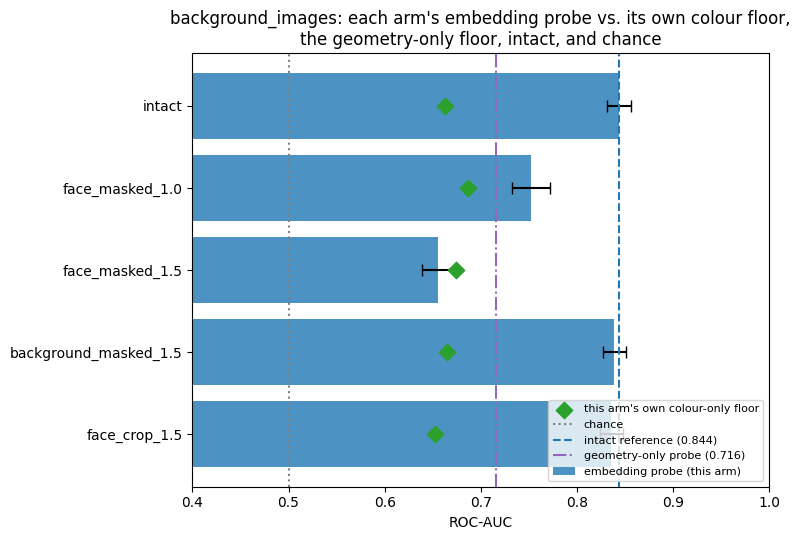

In [13]:
arm_order = list(cfg.arm_names)
y_pos = np.arange(len(arm_order))
means = [summary.loc[summary.arm == a, "roc_auc_mean"].item() for a in arm_order]
sds = [summary.loc[summary.arm == a, "roc_auc_sd"].item() for a in arm_order]
colour_means = [colour_summary.loc[colour_summary.arm == a, "roc_auc_mean"].item() for a in arm_order]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(y_pos, means, xerr=sds, color="tab:blue", alpha=0.8, capsize=4, label="embedding probe (this arm)")
ax.scatter(colour_means, y_pos, marker="D", s=70, color="tab:green", zorder=5,
           label="this arm's own colour-only floor")

ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="chance")
ax.axvline(intact_auc, color="tab:blue", linestyle="--", linewidth=1.5,
           label=f"intact reference ({intact_auc:.3f})")
ax.axvline(geometry_probe_auc_mean, color="tab:purple", linestyle="-.", linewidth=1.5,
           label=f"geometry-only probe ({geometry_probe_auc_mean:.3f})")

ax.set_yticks(y_pos)
ax.set_yticklabels(arm_order)
ax.set_xlabel("ROC-AUC")
ax.set_xlim(0.4, 1.0)
ax.set_title("background_images: each arm's embedding probe vs. its own colour floor,\nthe geometry-only floor, intact, and chance")
ax.legend(loc="lower right", fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 9. How to read it

The comparison that matters is each arm against **its own** colour and
geometry floors, not against 0.5.

| `face_masked_1.5` | `face_crop_1.5` | Reading |
|---|---|---|
| At its floors | Well above its floor | Signal is facial. The branch survives this test -- the strongest possible outcome |
| Well above its floors | At its floor | Signal is context: background, framing, composition. The branch fails |
| Both well above floors | | Signal is present in both regions. Likely a global acquisition property -- lighting, compression, capture style -- present everywhere in the frame |
| Both at their floors | | Nothing beyond colour and mask shape. Consistent with the blur result |

**What this run actually shows: the first row.** `face_crop_1.5` -- face
only, position and scale normalised away -- scores 0.836, a mere 0.008 AUC
below the full intact image (0.844) and 0.12-0.18 AUC above its own colour
(0.652) and geometry (0.716) floors. `background_masked_1.5` -- face kept
at its original position and scale, everything else removed -- scores
0.839, even closer to intact. Between them, these two arms recover
essentially all of the intact arm's signal from the face region alone, with
or without the possible position/scale leak that only `background_masked`
carries. `face_masked_1.5` -- background kept, face removed -- collapses
to 0.656: below its own colour floor (0.675) and well below the geometry
floor (0.716). The background, once the face is actually gone (not just
blurred), carries no signal beyond what colour and box shape already
explain on their own.

This is the strongest possible outcome for the facial-phenotype branch:
performance survives being reduced to the face region alone, at both its
original scale (`background_masked`) and normalised scale (`face_crop`),
and collapses when the face region specifically is removed. It also
resolves the ambiguity `blurred_images` could not: that experiment's 0.178
AUC decline as blur increased was consistent with either explanation, and
this one shows it was the face, not the frame around it.

**The box-expansion comparison matters on its own.** `face_masked_1.0`
(tight box masked, forehead/hair/ears left in the "background") scores
0.752 -- markedly higher than `face_masked_1.5`'s 0.656. A tight MTCNN box
is not "the face" in the sense this test needs; forehead, hair and ears
carry real signal, and a test built on the tight box alone would have
under-stated how much the face region matters. `expand=1.5` is the honest
number; `expand=1.0` is shown to make that dependency visible, not to be
read as a second, independent result.

**The geometry-only floor is not a formality here.** `box_area_fraction`
has a medium-to-large effect size by class (Cliff's delta -0.40) and
`box_centre_y` a medium one (+0.35) -- MTCNN's boxes are systematically
smaller and lower in one class than the other, at sigma=0, before any
masking happens. That is exactly the confound Part 1 exists to catch, and
it is why `face_masked_1.5` is read against 0.716, not 0.5: a naive
chance-only reading would have overstated how little a fully-masked image
reveals.

One number does not fit the tidy version of the story: `face_masked_1.5`'s
embedding AUC (0.656) is itself somewhat *below* the geometry-only probe's
0.716, even though the box's edges -- and therefore its shape -- are still
visible in the masked image as a discontinuity against the mean-colour
fill. A direct logistic regression on 4 clean geometry numbers is a much
easier estimation problem than recovering the same signal implicitly from
a frozen ResNet-50 embedding of an image with a rectangular hole in it, so
this reads as the embedding pathway being a lossy proxy for the box-shape
signal, not as a broken pipeline -- `face_crop_1.5` and `background_masked_1.5`
both behaving exactly as expected is the evidence the pipeline itself is
sound.

**Known limitation, carried over unchanged.** The same 11 near-duplicate
image pairs (5 crossing published-split boundaries) are pooled into
cross-validation here exactly as in `intact_images` and `blurred_images`.
Because every arm reuses the same manifest, fold assignment and seed, this
leakage affects every arm identically -- it shifts every bar in the figure
above by the same small amount and does not distort the *comparison*
between arms. `repeated_stratified_cv`'s `groups=` parameter remains the
seam where the fix goes once perceptual-hash grouping exists.